Sample Data: deterministic but larger

# Setup

In [110]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
  
dataset = pd.read_csv('csvs/case_rate_sample_long.csv')

# Exploratory Data Analysis (EDA)

In [111]:
dataset.head()

,case_rate_id,description,cases,customers,customer_type,ratio,period,period_count
0,1,High case rate for dentists,120,30,dentist,4.0,Day,1
1,2,Moderate case rate for dentists,80,40,dentist,2.0,Week,1
2,3,Low case rate for dentists,50,50,dentist,1.0,Month,1
3,4,High case rate for offices,200,20,office,10.0,Day,1
4,5,Moderate case rate for offices,150,30,office,5.0,Week,1


In [112]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3610 entries, 0 to 3609
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_rate_id   3610 non-null   int64  
 1   description    3610 non-null   object 
 2   cases          3610 non-null   int64  
 3   customers      3610 non-null   int64  
 4   customer_type  3610 non-null   object 
 5   ratio          3610 non-null   float64
 6   period         3610 non-null   object 
 7   period_count   3610 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 225.8+ KB


In [113]:
dataset.describe()

,case_rate_id,cases,customers,ratio,period_count
count,3610.00000,3610.000000,3610.000000,3610.000000,3610.0
mean,5.46205,174.604432,32.654017,10.480777,1.0
std,2.83788,72.171203,10.404148,5.515965,0.0
min,1.00000,50.000000,15.000000,1.000000,1.0
25%,3.00000,112.000000,24.000000,5.782711,1.0
50%,6.00000,175.000000,33.000000,10.459035,1.0
75%,8.00000,237.000000,42.000000,15.313996,1.0
max,10.00000,300.000000,50.000000,20.000000,1.0


In [114]:
dataset.isnull().any() 

case_rate_id     False
description      False
cases            False
customers        False
customer_type    False
ratio            False
period           False
period_count     False
dtype: bool

### Minor Data Processing to Analyze as Needed

In [115]:
dataset = dataset.drop(columns=['case_rate_id'])


In [116]:
# dataset["description"].fillna(dataset["description"].mode()[0],inplace = True) 

### Label Encoding
Transform textual data to numerical. 

In [117]:
label_encoder = LabelEncoder()
dataset['description'] = label_encoder.fit_transform(dataset['description'])
dataset['customer_type'] = label_encoder.fit_transform(dataset['customer_type'])
dataset['period'] = label_encoder.fit_transform(dataset['period'])

In [118]:
dataset.head()

,description,cases,customers,customer_type,ratio,period,period_count
0,0,120,30,0,4.0,0,1
1,6,80,40,0,2.0,2,1
2,3,50,50,0,1.0,1,1
3,1,200,20,1,10.0,0,1
4,7,150,30,1,5.0,2,1


### Heatmap

<Axes: >

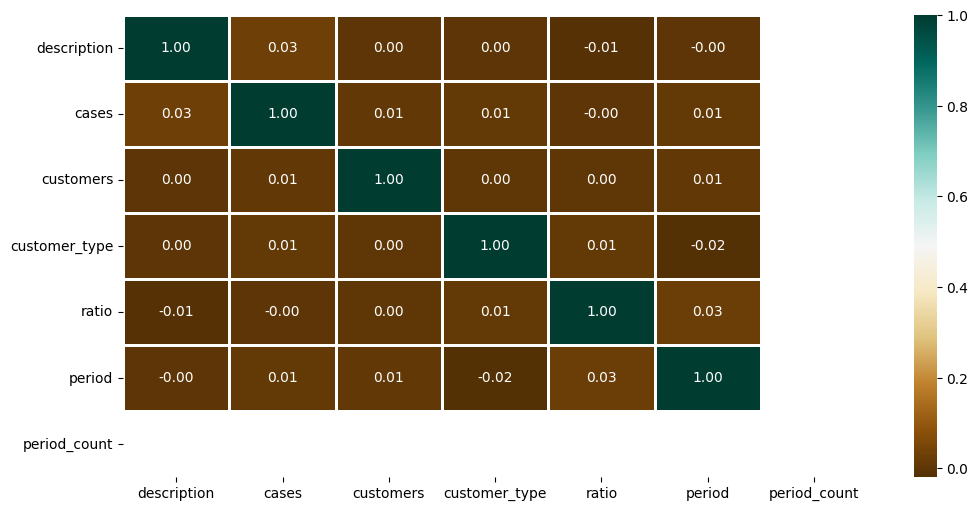

In [119]:
plt.figure(figsize=(12,6)) 

sns.heatmap(dataset.corr(), 
			cmap='BrBG', 
			fmt='.2f', 
			linewidths=2, 
			annot=True)


In [120]:
dataset.head()

,description,cases,customers,customer_type,ratio,period,period_count
0,0,120,30,0,4.0,0,1
1,6,80,40,0,2.0,2,1
2,3,50,50,0,1.0,1,1
3,1,200,20,1,10.0,0,1
4,7,150,30,1,5.0,2,1


### Histogram

In [121]:
# lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
# plt.subplots(figsize=(15, 8)) 
# index = 1

# # `distplot` is a deprecated function and will be removed in seaborn v0.14.0.

# # Please adapt your code to use either `displot` (a figure-level function with
# # similar flexibility) or `histplot` (an axes-level function for histograms).

# # For a guide to updating your code to use the new functions, please see
# # https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


# for i in lis: 
# 	plt.subplot(2, 2, index) 
# 	sns.distplot(dataset[i]) 
# 	index += 1


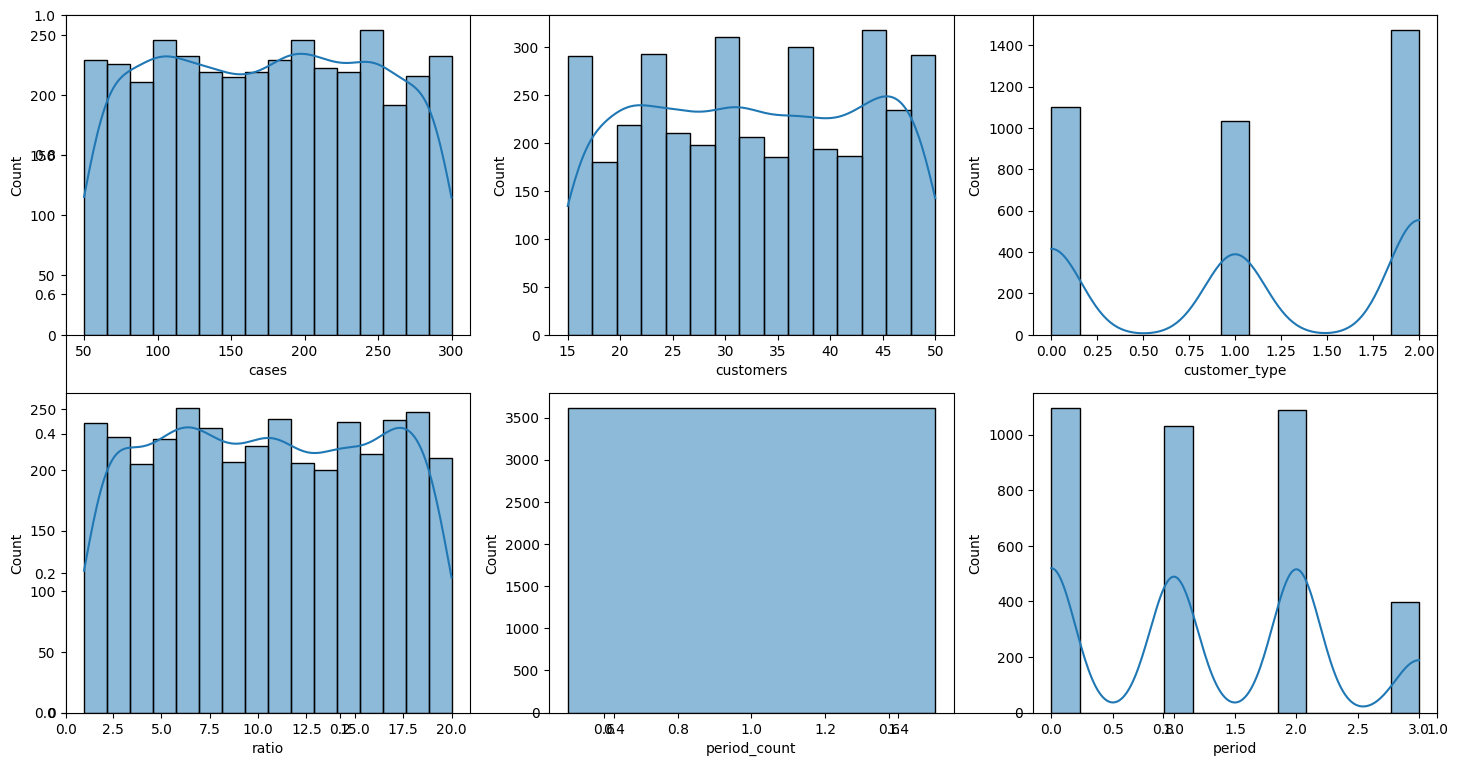

In [122]:
lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
plt.subplots(figsize=(15, 8)) 
index = 1

for i in lis: 
    plt.subplot(2, 3, index) 
    sns.histplot(dataset[i], kde=True) 
    index += 1

plt.tight_layout()
plt.show()

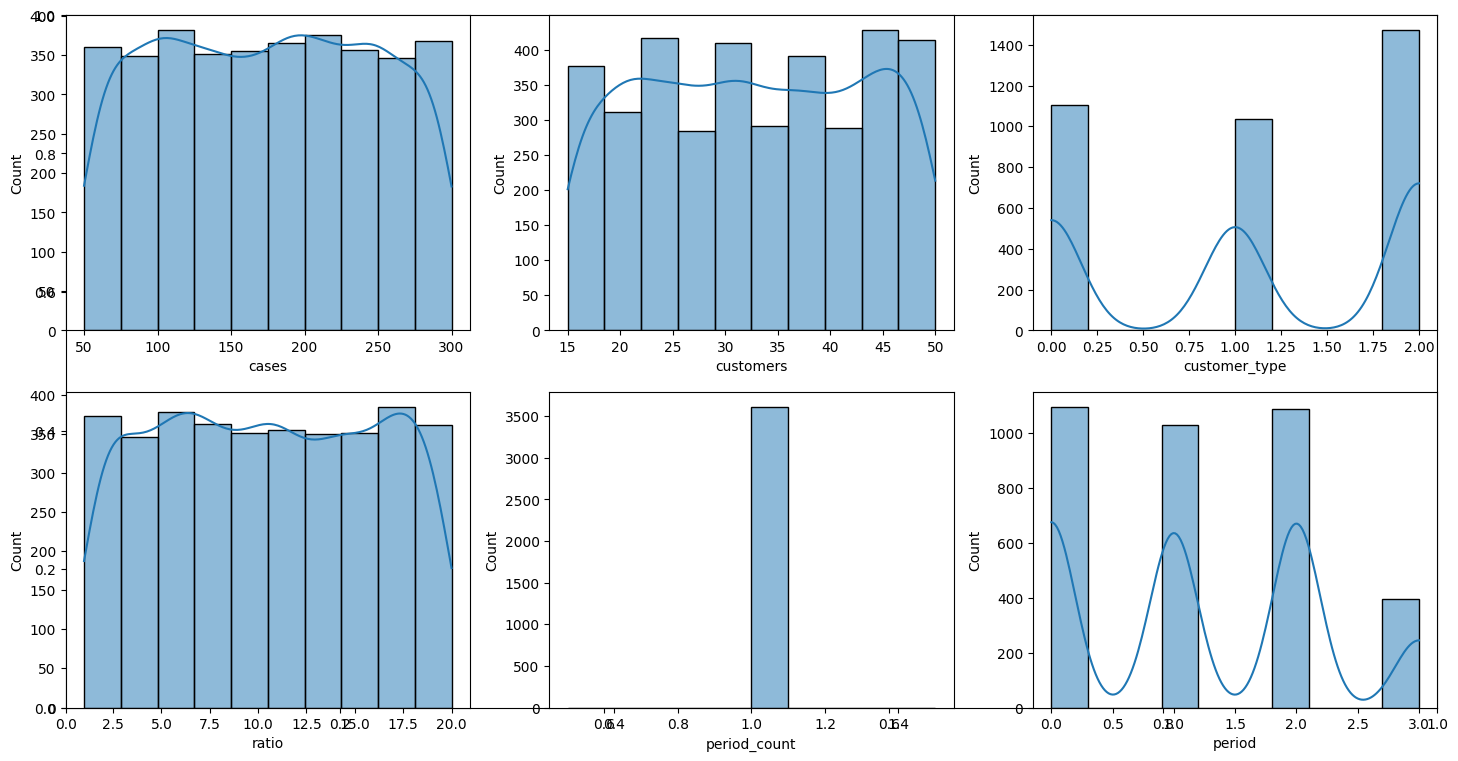

In [123]:
lis = ['cases', 'customers', 'customer_type', 'ratio', 'period_count', 'period'] 
plt.subplots(figsize=(15, 8)) 
index = 1

for i in lis: 
    plt.subplot(2, 3, index) 
    sns.histplot(dataset[i], bins=10, kde=True) 
    index += 1

plt.tight_layout()
plt.show()

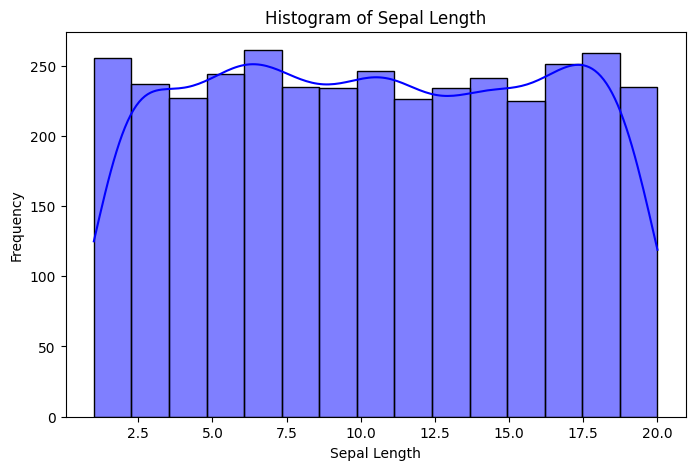

In [124]:
# Plot histogram for sepal_length
plt.figure(figsize=(8, 5))
sns.histplot(dataset['ratio'], bins=15, kde=True, color='blue')
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.show()

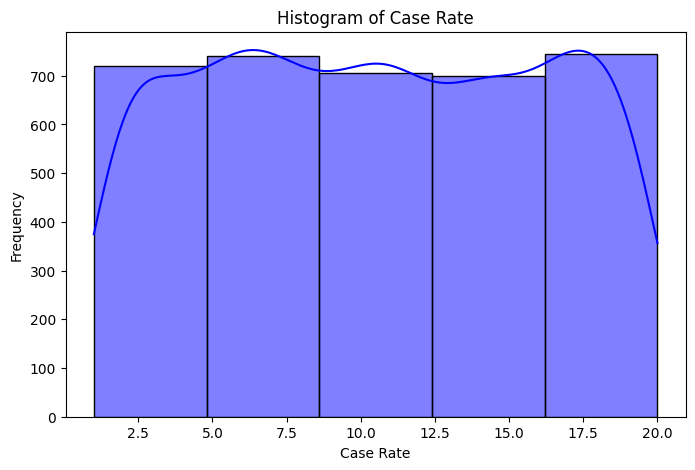

In [125]:
# Plot histogram for sepal_length
plt.figure(figsize=(8, 5))
sns.histplot(dataset['ratio'], bins=5, kde=True, color='blue')
plt.title('Histogram of Case Rate')
plt.xlabel('Case Rate')
plt.ylabel('Frequency')
plt.show()

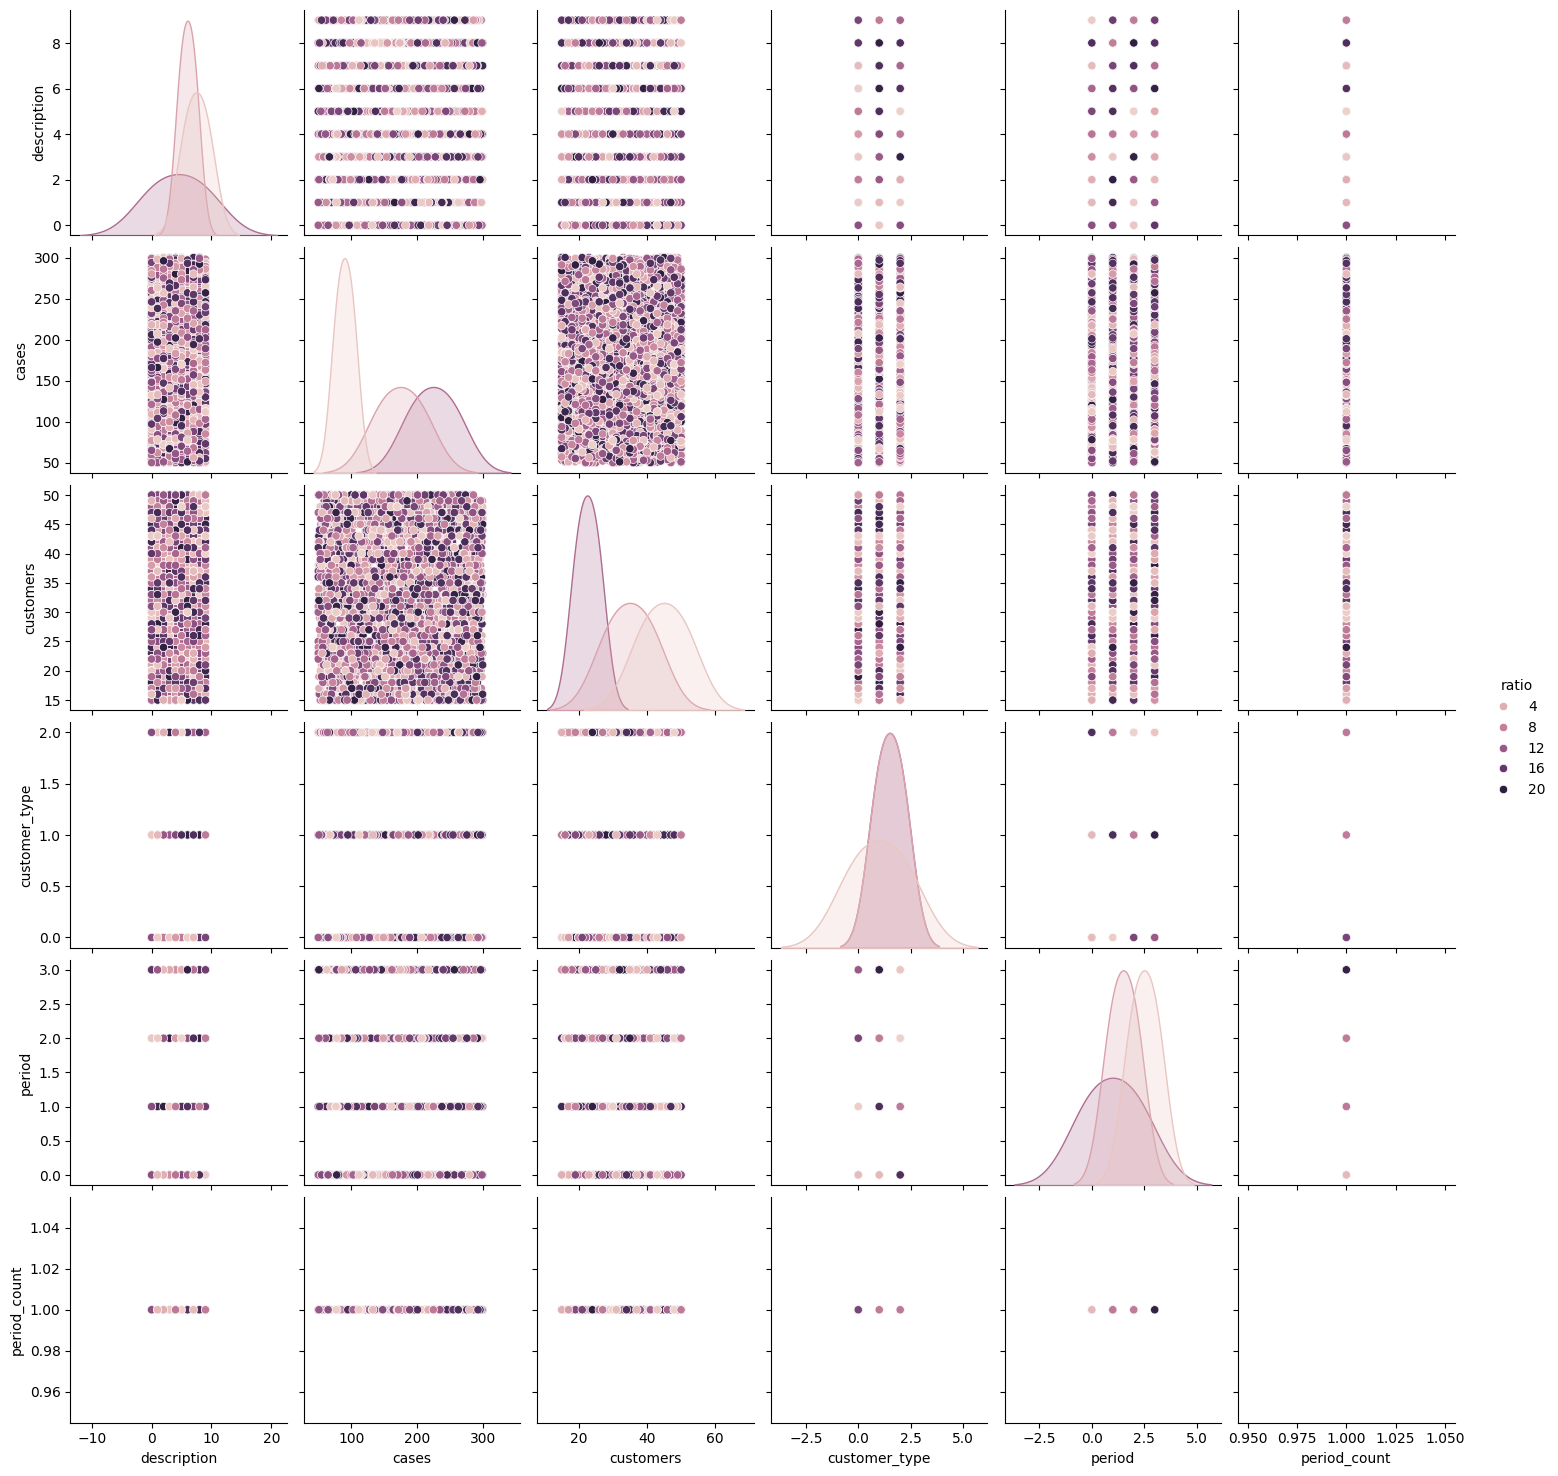

In [126]:
sns.pairplot(dataset, hue='ratio', diag_kind='kde')
plt.show()

# Data Preprocessing

In [127]:
dataset.isnull().any()

description      False
cases            False
customers        False
customer_type    False
ratio            False
period           False
period_count     False
dtype: bool

### Pick Prediction Target

In [128]:
y = dataset.ratio
y

0        4.000000
1        2.000000
2        1.000000
3       10.000000
4        5.000000
          ...    
3605     1.042875
3606    14.409601
3607     3.033215
3608     8.444854
3609     8.656690
Name: ratio, Length: 3610, dtype: float64

### Pick Features

In [178]:
features = ["cases", "customers","customer_type", "period", "period_count"]

X = dataset[features]
X

,cases,customers,customer_type,period,period_count
0,120,30,0,0,1
1,80,40,0,2,1
2,50,50,0,1,1
3,200,20,1,0,1
4,150,30,1,2,1
...,...,...,...,...,...
3605,170,48,2,2,1
3606,189,21,0,2,1
3607,133,31,1,0,1
3608,172,50,1,2,1


In [130]:
X.describe()

,cases,customers,customer_type,period,period_count
count,3610.000000,3610.000000,3610.000000,3610.000000,3610.0
mean,174.604432,32.654017,1.101939,1.217729,1.0
std,72.171203,10.404148,0.838676,0.998595,0.0
min,50.000000,15.000000,0.000000,0.000000,1.0
25%,112.000000,24.000000,0.000000,0.000000,1.0
50%,175.000000,33.000000,1.000000,1.000000,1.0
75%,237.000000,42.000000,2.000000,2.000000,1.0
max,300.000000,50.000000,2.000000,3.000000,1.0


### Splitting Dependent and Independent Variables

### Via iloc (NEEDS WORk)

In [131]:
x_temp = dataset.iloc[:,0:4].values 
y_temp = dataset.iloc[:,13:14].values
x_temp

array([[  0, 120,  30,   0],
       [  6,  80,  40,   0],
       [  3,  50,  50,   0],
       ...,
       [  1, 133,  31,   1],
       [  9, 172,  50,   1],
       [  4, 225,  27,   2]], shape=(3610, 4))

In [132]:
x_train, x_test, y_train, y_test = train_test_split(X,y, 
													test_size = 0.2, 
													random_state = 0)


In [133]:
x_train

,cases,customers,customer_type,period,period_count
1610,203,39,1,3,1
2973,216,42,2,0,1
701,106,21,2,2,1
3049,112,37,1,1,1
3593,64,46,2,0,1
...,...,...,...,...,...
835,213,35,1,2,1
3264,212,22,0,1,1
1653,122,30,2,0,1
2607,293,47,1,1,1


In [134]:
x_test

,cases,customers,customer_type,period,period_count
3400,117,41,1,1,1
2794,220,21,1,1,1
546,163,26,1,2,1
2318,161,21,0,2,1
1082,146,31,0,1,1
...,...,...,...,...,...
3347,152,48,2,0,1
385,169,20,0,1,1
3309,248,15,2,1,1
2954,284,17,1,0,1


In [135]:
x_train.describe()

,cases,customers,customer_type,period,period_count
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.0
mean,175.221260,32.691136,1.096260,1.229917,1.0
std,72.189163,10.392313,0.837971,1.001443,0.0
min,50.000000,15.000000,0.000000,0.000000,1.0
25%,113.000000,24.000000,0.000000,0.000000,1.0
50%,178.000000,33.000000,1.000000,1.000000,1.0
75%,237.000000,42.000000,2.000000,2.000000,1.0
max,300.000000,50.000000,2.000000,3.000000,1.0


### Feature Scaling

In [136]:
sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 
x_test = sc.fit_transform(x_test)

In [137]:
x_train

array([[ 0.38487148,  0.6071754 , -0.11489302,  1.76783947,  0.        ],
       [ 0.5649851 ,  0.89590029,  1.07867191, -1.22835794,  0.        ],
       [-0.9590532 , -1.12517399,  1.07867191,  0.769107  ,  0.        ],
       ...,
       [-0.7373749 , -0.2589993 ,  1.07867191, -1.22835794,  0.        ],
       [ 1.63181191,  1.37710846, -0.11489302, -0.22962547,  0.        ],
       [-1.06989235, -1.22141562, -0.11489302, -1.22835794,  0.        ]],
      shape=(2888, 5))

In [138]:
# x_train.describe()

# Modeling

## Regression - Decision Tree Algorithm

In [139]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=1)

# does this work?? 
model.fit(X, y)

DecisionTreeRegressor(random_state=1)

In [140]:
model = DecisionTreeRegressor(random_state=1)

model.fit(x_train, y_train)


DecisionTreeRegressor(random_state=1)

In [141]:
predictions = model.predict(x_test)
predictions

array([ 9.89299353,  8.4988439 , 19.83499596, 14.88557863, 18.90239799,
        4.72608942,  8.69859743,  2.63112964, 17.78325824, 13.88430513,
       12.44988037, 16.89146284,  1.49685742,  1.78879336, 11.7055085 ,
        1.49685742, 14.2185968 , 10.72118333,  2.67914609, 12.02296071,
        9.50573123, 19.57131582, 13.21921393, 11.81110036,  7.36390288,
       17.8456691 , 14.33820021,  6.46482863, 15.25955726, 10.72118333,
        5.69392278, 18.42688966, 18.03031753, 18.85712933,  2.84961654,
        7.40045973, 16.34330248,  9.51723155, 11.70525005, 16.15241758,
        2.96291323, 17.93822764, 12.50871697,  2.14524092,  5.09331596,
        4.81073078, 15.92564726,  5.41931279,  4.62491438,  1.98985715,
        8.08148966,  9.57623765, 19.55081252,  9.56469693, 16.22001402,
        1.6948408 , 17.9352179 ,  2.01735747, 17.5818242 ,  9.1527591 ,
        9.82235022,  5.84114576, 19.62031358, 14.97419601,  1.24970235,
       18.92477586, 18.77599572, 18.44594235,  1.37091528, 15.10

In [142]:
from sklearn.metrics import average_precision_score

# avg_precision = average_precision_score(y_test, predictions)
# Convert y_test and predictions to binary values for average_precision_score
y_test_binary = [1 if actual >= 0.5 else 0 for actual in y_test]
predictions_binary = [1 if pred >= 0.5 else 0 for pred in predictions]

avg_precision = average_precision_score(y_test_binary, predictions_binary)
avg_precision


np.float64(1.0)

In [143]:
# from sklearn.metrics import average_precision_score

# y_pred_proba = model.predict_proba(x_test)[:, 1]
# avg_precision = average_precision_score(y_test, y_pred_proba)
# avg_precision

In [144]:
from sklearn import metrics 
from sklearn.metrics import average_precision_score

# as_metric = 100*metrics.accuracy_score(y_test, predictions)

# Convert predictions and y_test to binary values for accuracy_score
predictions_binary = [1 if pred >= 0.5 else 0 for pred in predictions]
y_test_binary = [1 if actual >= 0.5 else 0 for actual in y_test]

as_metric = 100 * metrics.accuracy_score(y_test_binary, predictions_binary)

as_metric

100.0

In [145]:
from sklearn.metrics import mean_absolute_error

mae_metric = mean_absolute_error(y_test, predictions)
mae_metric

6.4900146310189735

## Regression - Linear

In [231]:
from sklearn.linear_model import LinearRegression

from sklearn import metrics 
from sklearn.metrics import mean_squared_error, r2_score

lr_basic = LinearRegression()


# get standardized data
# X, y = shap.datasets.california()
# scaler = sklearn.preprocessing.StandardScaler()
# scaler.fit(X)
# X_std = scaler.transform(X)

# train the linear model
# model = sklearn.linear_model.LinearRegression().fit(X_std, y)

lr_basic.fit(x_train, y_train)

# Make prediction on the testing data
y_pred = lr_basic.predict(x_test)

# Use regression metrics for evaluation
mse = mean_squared_error(y_test, y_pred)
mae_metric = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, y_pred)
# print(f"Model: {clf.__class__.__name__}")
# print(f"Mean Squared Error: {mse}")
# print(f"R² Score: {r2}")
# Accuracy score of  LogisticRegression = 5.678670360110803
print(f"Mean Squared Error of {lr_basic.__class__.__name__} = {mse} | R² Score = {r2} | MAE = {mae_metric}")


# explain the model's predictions using SHAP
# explainer = shap.explainers.Linear(model, X_std)
# shap_values = explainer(X_std)

# visualize the model's dependence on the first feature
# shap.plots.scatter(shap_values[:, 0])

# Re-run the classifiers with the converted target variables
# for clf in (rfr, lc):
# for clf in (rfr, lr, dtr):
# 	clf.fit(x_train, y_train)  # Use continuous y_train for regression
# 	y_pred = clf.predict(x_test)
	
#    	# Use regression metrics for evaluation
# 	mse = mean_squared_error(y_test, y_pred)
# 	mae_metric = mean_absolute_error(y_test, predictions)
# 	r2 = r2_score(y_test, y_pred)
# 	# print(f"Model: {clf.__class__.__name__}")
# 	# print(f"Mean Squared Error: {mse}")
# 	# print(f"R² Score: {r2}")
# 	# Accuracy score of  LogisticRegression = 5.678670360110803
# 	print(f"Mean Squared Error of {clf.__class__.__name__} = {mse} | R² Score = {r2} | MAE = {mae_metric}")


Mean Squared Error of LinearRegression = 31.725918029412995 | R² Score = -0.006722443226545138 | MAE = 6.4900146310189735


## Classification - RandomForestClassifier

In [172]:
# Taken from https://www.datacamp.com/tutorial/introduction-to-shap-values-machine-learning-interpretability

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# X = customer.drop("Churn", axis=1) # Independent variables
# y = customer.Churn # Dependent variable

# Split into train and test 
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Convert y_test and y_train to integer values for classification
y_train_class = y_train.astype(int)
y_test_class = y_test.astype(int)

# Train a machine learning model
from sklearn.ensemble import RandomForestClassifier
rfc_basic = RandomForestClassifier()
# clf.fit(x_train, y_train)
rfc_basic.fit(x_train, y_train_class)

# Make prediction on the testing data
y_pred = rfc_basic.predict(x_test)

# Classification Report
# print(classification_report(y_pred, y_test))
print(classification_report(y_pred, y_test_class))


              precision    recall  f1-score   support

           1       0.14      0.11      0.12        44
           2       0.07      0.10      0.08        31
           3       0.05      0.06      0.05        33
           4       0.12      0.10      0.11        42
           5       0.14      0.11      0.12        46
           6       0.10      0.08      0.09        51
           7       0.06      0.05      0.05        39
           8       0.17      0.11      0.13        47
           9       0.00      0.00      0.00        33
          10       0.00      0.00      0.00        37
          11       0.03      0.03      0.03        40
          12       0.09      0.10      0.09        31
          13       0.06      0.07      0.07        27
          14       0.05      0.04      0.05        47
          15       0.10      0.15      0.12        20
          16       0.05      0.10      0.07        31
          17       0.09      0.08      0.09        49
          18       0.07    

## Multi-Algorithm 

May need more data to validate better.

In [149]:
print(y_train[:10])  # Check the first 10 values of y_train
print(y_test[:10])   # Check the first 10 values of y_test

1610     4.924501
2973    17.466454
701      8.902940
3049     7.973386
3593    10.692427
2072    17.074458
1129    16.528636
1003     8.018532
2284    19.273984
1174     7.685950
Name: ratio, dtype: float64
3400     1.807132
2794    17.455425
546     14.695966
2318     3.168078
1082     4.111244
3584     1.650498
3020    18.636445
514     11.487446
473      5.284301
840      6.365195
Name: ratio, dtype: float64


In [147]:
y_test_class

3400     1
2794    17
546     14
2318     3
1082     4
        ..
3347    11
385     18
3309    18
2954    17
2883    18
Name: ratio, Length: 722, dtype: int64

### Regression Models

Split for Continuous Targets, those with float values. 

Mean Squared Error (MSE):
Measures the average squared difference between the predicted and actual values; smaller values indicate better model performance but penalize larger errors more heavily.

Mean Absolute Error (MAE):
Measures the average absolute difference between the predicted and actual values; smaller values indicate better performance and it is less sensitive to outliers compared to MSE.

R² Score (Coefficient of Determination):
Indicates how well the model explains the variance in the target variable; values closer to 1 mean the model fits the data well, while values near 0 indicate poor fit.

For example, an R² Score of -0.22 means that your model is performing worse than a simple baseline model that always predicts the mean of the target variable. Here's how to interpret it:

Positive R² (0 to 1): Indicates how much variance in the target variable is explained by the model. Closer to 1 means a better fit.
R² = 0: The model explains none of the variance and performs as poorly as predicting the mean of the target.
Negative R² (< 0): The model performs worse than the baseline (mean prediction). This suggests that the model's predictions are not capturing the relationship between the features and the target variable effectively.

In [164]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn import metrics 
from sklearn.metrics import mean_squared_error, r2_score

rfr = RandomForestRegressor(n_estimators=100, random_state=7)
# lc = LogisticRegression() 
lr = LinearRegression()
dtr = DecisionTreeRegressor(random_state=1)

# Re-run the classifiers with the converted target variables
# for clf in (rfr, lc):
for clf in (rfr, lr, dtr):
	clf.fit(x_train, y_train)  # Use continuous y_train for regression
	y_pred = clf.predict(x_test)
	
   	# Use regression metrics for evaluation
	mse = mean_squared_error(y_test, y_pred)
	mae_metric = mean_absolute_error(y_test, predictions)
	r2 = r2_score(y_test, y_pred)
	# print(f"Model: {clf.__class__.__name__}")
	# print(f"Mean Squared Error: {mse}")
	# print(f"R² Score: {r2}")
	# Accuracy score of  LogisticRegression = 5.678670360110803
	print(f"Mean Squared Error of {clf.__class__.__name__} = {mse} | R² Score = {r2} | MAE = {mae_metric}")
	

	




Mean Squared Error of RandomForestRegressor = 38.46412056784586 | R² Score = -0.22053815428516543 | MAE = 6.4900146310189735
Mean Squared Error of LinearRegression = 31.725918029412995 | R² Score = -0.006722443226545138 | MAE = 6.4900146310189735
Mean Squared Error of DecisionTreeRegressor = 63.127843914996184 | R² Score = -1.0031640125530772 | MAE = 6.4900146310189735


### Classification Models

Expect target variable to represent distinct classes, not continuous values.

Classifiers expect y_train and y_test to contain integers or categorical values representing class labels (e.g., 0, 1, 2, etc.).

For example, the accuracy score 7.756232686980609, seems unusually low (around 7.76%). This suggests that the model is performing poorly, likely worse than random guessing in most cases. Here's how to interpret and evaluate accuracy scores:

1. What is a "Good" Accuracy Score?
- A "good" accuracy score depends on the problem and the dataset. For example:
-- Binary classification: If the classes are balanced, random guessing would give ~50% accuracy. A good model should significantly outperform this baseline.
-- Multiclass classification: If there are n classes, random guessing would give an accuracy of 1/n. A good model should exceed this baseline by a large margin.
In general, a good accuracy score is one that is significantly better than random guessing and meets the requirements of your specific application.
2. Why is Your Accuracy So Low?
- Data issues: Check if your y_train and y_test labels are correct and properly preprocessed. For example, if they are continuous values instead of discrete class labels, the model will fail to classify correctly.
- Model configuration: The RandomForestClassifier is using only 7 estimators (n_estimators=7), which is very low. Increasing this value (e.g., to 100 or more) can improve performance.
- Feature quality: Ensure that your x_train and x_test features are meaningful and properly scaled if necessary.
- Class imbalance: If one class dominates the dataset, accuracy may not be a good metric. Consider using metrics like precision, recall, or F1-score.
3. Next Steps to Improve Accuracy
- Increase n_estimators: For RandomForestClassifier, try setting n_estimators=100 or higher.
- Check data preprocessing: Ensure x_train, x_test, y_train, and y_test are correctly formatted and scaled.
- Evaluate other metrics: Use metrics like precision, recall, F1-score, or a confusion matrix to get a better understanding of model performance.
- Hyperparameter tuning: Use grid search or random search to optimize hyperparameters for your models.

In [170]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn import metrics 
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=3) 
rfc = RandomForestClassifier(n_estimators = 7, 
							criterion = 'entropy', 
							random_state =7) 

# Getting "ValueError: Classification metrics can't handle a mix of continuous and multiclass targets"
# hgbc = HistGradientBoostingClassifier(
# 	learning_rate=0.1,  # A common default value for learning rate
# 	max_depth=10,       # A reasonable depth to prevent overfitting
# 	l2_regularization=1.0,  # Default value for regularization
# 	random_state=42
# )

svc = SVC() 
lc = LogisticRegression() 
# dtr = DecisionTreeRegressor(random_state=1)

# making predictions on the training set 
# for clf in (rfc, knn, svc,lc): 
# 	# clf.fit(x_train, y_train) 
# 	clf.fit(x_train, y_train.astype(int))
# 	y_pred = clf.predict(x_test) 
# 	print("Accuracy score of ",clf.__class__.__name__,"=", 
# 		100*metrics.accuracy_score(y_test, y_pred))

# Convert y_test and y_train to integer values for classification
y_train_class = y_train.astype(int)
y_test_class = y_test.astype(int)

# Re-run the classifiers with the converted target variables
for clf in (rfc, knn, svc, lc):
	clf.fit(x_train, y_train_class)
	y_pred = clf.predict(x_test)
	print("Accuracy score of ", clf.__class__.__name__, "=", 
			100 * metrics.accuracy_score(y_test_class, y_pred))
	# Classification Report
	# print(classification_report(y_pred, y_test_class))


Accuracy score of  RandomForestClassifier = 7.756232686980609
Accuracy score of  KNeighborsClassifier = 7.756232686980609
Accuracy score of  SVC = 5.124653739612189
Accuracy score of  LogisticRegression = 5.678670360110803


# Exploratory Analysis

In [280]:
# To identify what feature 0 corresponds to, you can check the columns of the original dataset or the features used for training.
print("Feature 0 corresponds to:", features[0])


Feature 0 corresponds to: cases


In [281]:
print(f"The name of the target variable (y) is: {y.name}")

The name of the target variable (y) is: ratio


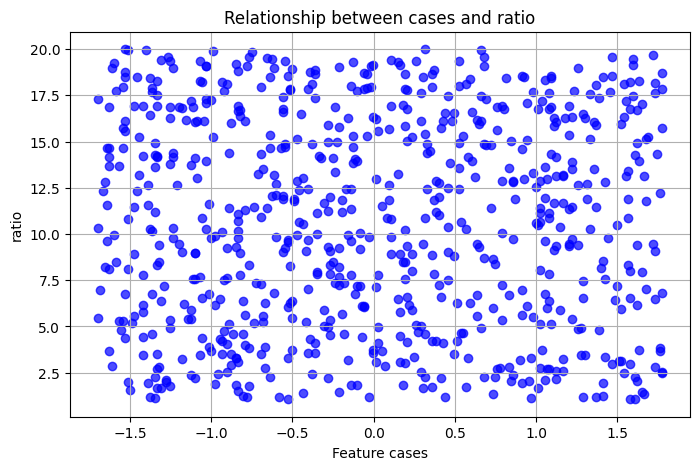

In [282]:
plt.figure(figsize=(8, 5))
plt.scatter(x_test[:, 0], y_test, alpha=0.7, color='blue')
plt.title(f'Relationship between {features[0]} and {y.name}')
plt.xlabel(f'Feature {features[0]}')
plt.ylabel(f'{y.name}')
plt.grid(True)
plt.show()


# SHAP Analysis - RandomForestClassifier Basic

### Check Multi-Class

Impacts SHAP Analysis as it will show all unique classes.

Why Are There Many Classes?
- Multiclass Classification: If your target variable (y_train or y_test) has multiple unique class labels (e.g., 0, 1, 2, etc.), SHAP will compute explanations for each class separately. Each "class" corresponds to one of the possible output labels of your model.
- SHAP Values for Each Class: For a multiclass model, SHAP calculates the contribution of each feature to the probability of each class. The shap.summary_plot shows these contributions for all classes.

Why SHAP Shows Many Classes
1. Model Output: SHAP generates explanations based on the model's predictions. If your model is a multiclass classifier, it outputs probabilities for each class (e.g., for 3 classes, the output might be [0.2, 0.5, 0.3] for a single prediction). SHAP calculates feature contributions for each class separately.

2. SHAP Values for Multiclass Models: When you pass shap_values to shap.summary_plot, it contains SHAP values for all classes. For a multiclass model, shap_values is a list or array where each element corresponds to the SHAP values for one class.

3. x_test: The x_test input is used to map feature names and values to the SHAP values. It does not directly determine the number of classes.

In [229]:
print(rfc_basic.classes_)  # For RandomForestClassifier

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [223]:
y_train

1610     4.924501
2973    17.466454
701      8.902940
3049     7.973386
3593    10.692427
          ...    
835     11.724582
3264    15.579131
1653    14.530977
2607     8.142823
2732     4.862080
Name: ratio, Length: 2888, dtype: float64

In [226]:
set(y_train)

{1.0,
 2.0,
 2.290906726810338,
 4.924500544625573,
 4.48897180963948,
 6.525232323210162,
 7.973385855519986,
 8.01853157326316,
 9.376426282071932,
 5.0,
 6.801232518367868,
 6.408549487809722,
 13.231410013137996,
 5.982819702368829,
 15.793766819992314,
 16.52863562691045,
 17.46645422911562,
 18.224632257886153,
 17.07445794688632,
 19.27398386639872,
 16.367207212292833,
 16.816165489322675,
 19.697547748380885,
 18.57302572970673,
 18.604409962350097,
 19.59445176875184,
 18.09148188144519,
 19.718096761018273,
 20.0,
 16.778812548277703,
 6.751563201560998,
 5.273743539864199,
 8.36907537429147,
 8.8007861585113,
 8.081489664744822,
 8.589715011067938,
 10.845476508550178,
 10.713985671563591,
 10.0,
 10.586299944555776,
 11.151284511546123,
 2.5,
 12.536352558364683,
 12.995353392906395,
 12.516215113764474,
 13.09384456173052,
 14.043968430960035,
 14.15441716166265,
 15.668960710274746,
 3.6296796982772728,
 16.72623365634729,
 16.67452026849878,
 16.07891214839708,
 16.5944

In [225]:
len(set(y_train))

2887

In [218]:
y_train_class

1610     4
2973    17
701      8
3049     7
3593    10
        ..
835     11
3264    15
1653    14
2607     8
2732     4
Name: ratio, Length: 2888, dtype: int64

In [219]:
y_test_class

3400     1
2794    17
546     14
2318     3
1082     4
        ..
3347    11
385     18
3309    18
2954    17
2883    18
Name: ratio, Length: 722, dtype: int64

In [220]:
print(set(y_train_class))  # Check unique classes in the training data

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20}


If you see many in the set above but its not meant to be a multiclass classification then you may need to consider more preprocessing so (y_train and y_test) contains the expected number of unique classes. Could this impact accuracy?

## Explainer

In [197]:
# taken in part from https://www.datacamp.com/tutorial/introduction-to-shap-values-machine-learning-interpretability

import shap

explainer = shap.Explainer(rfc_basic)
# explainer = shap.TreeExplainer(rfc_basic)
# shap_values = explainer.shap_values(x_test)
shap_values = explainer(x_test)


Mismatch in SHAP values dimensions: shap_values has 20 features, but x_test has 5.


In [230]:
# Should equal the number of classes for multiclass models
print(len(shap_values))  
# SHAP values for the first class
print(shap_values[0].shape)  

722
(5, 20)


In [198]:
shap_values[0].shape

(5, 20)

In [203]:
label_encoder.classes_

array(['Day', 'Month', 'Week', 'Year'], dtype=object)

In [202]:
# To understand what class 13 represents, you can map the encoded labels back to their original values.
# Assuming 'description' was the column encoded using LabelEncoder:

# Retrieve the mapping of encoded labels to original values
class_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

class_mapping

# Print the original value for class 13
# print(f"Class 13 corresponds to: {class_mapping[13]}")

{np.int64(0): 'Day',
 np.int64(1): 'Month',
 np.int64(2): 'Week',
 np.int64(3): 'Year'}

## Feature Importance

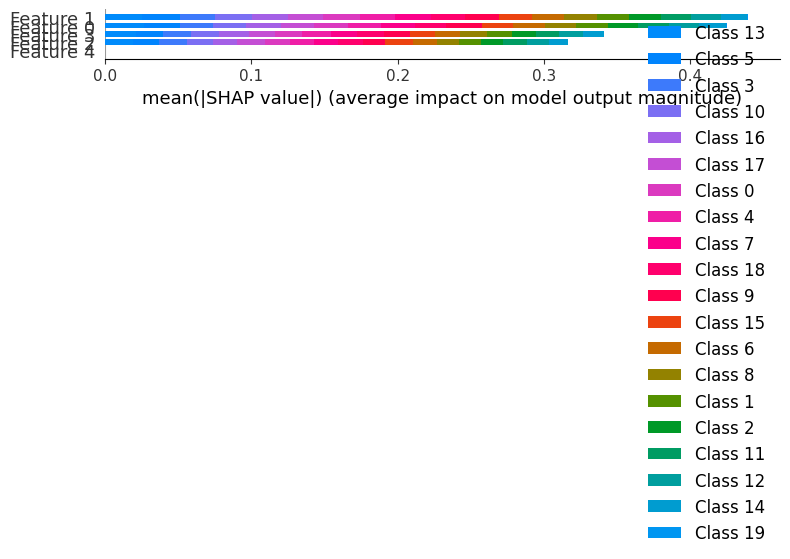

In [199]:
shap.summary_plot(shap_values, x_test)


How to Interpret the Plot
- Horizontal Axis: The magnitude of SHAP values, which indicates the impact of a feature on the model's predictions.
- Vertical Axis: The features ranked by their importance (average SHAP value across all samples).
- Colors: Represent the feature values (e.g., red for high values, blue for low values).
- Multiple Classes: If there are multiple classes, SHAP generates separate plots for each class, or it may combine them into one plot depending on the configuration.

### Single Class Plot

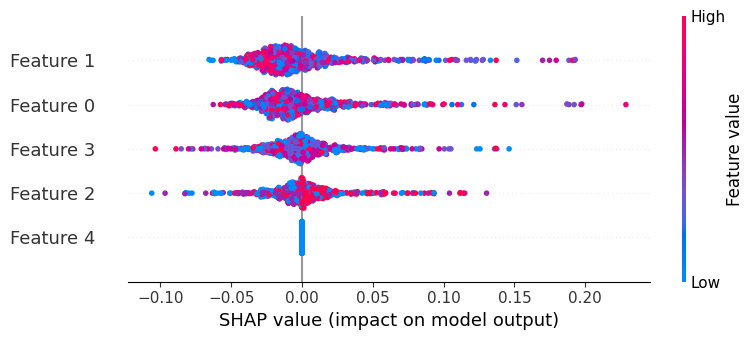

In [227]:
shap.summary_plot(shap_values[:, :, 0], x_test)

## Mean Absolute SHAP

Important Features with Best Model


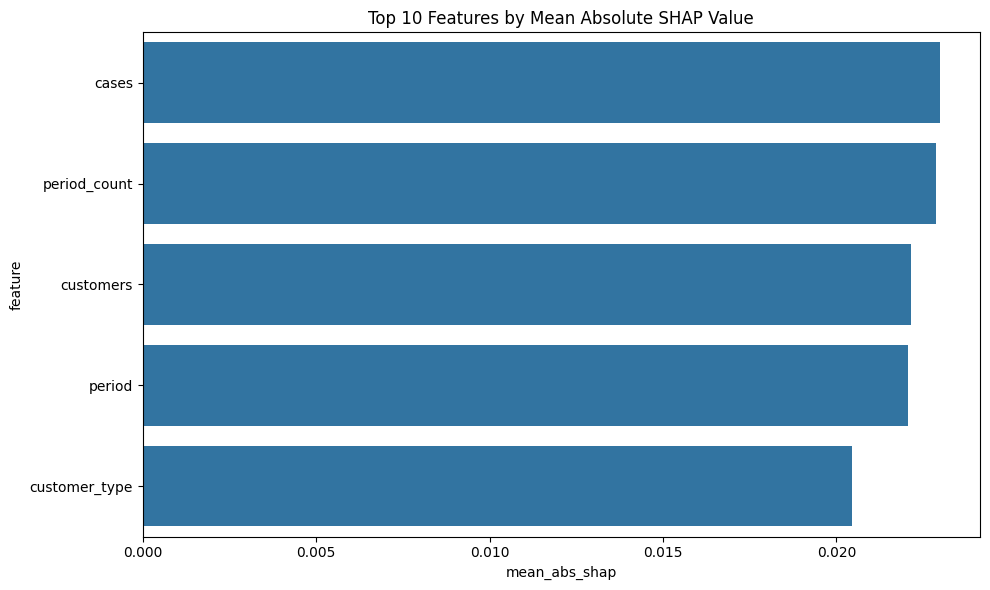

In [211]:
# Compute mean absolute SHAP values for feature importance
import seaborn as sns

mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)
# len(mean_abs_shap.flatten())
feature_importances = pd.DataFrame({
    'feature': features,
    # below line sets length to match but feels like it should be better done earlier
    'mean_abs_shap': mean_abs_shap.flatten()[:len(features)]
}).sort_values('mean_abs_shap', ascending=False)

# Subset to only the top 10 features
top_features = feature_importances.head(25)

print('Important Features with Best Model')
# Feature importance plot based on mean absolute SHAP values for the top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x='mean_abs_shap', y='feature', data=top_features)
plt.title('Top 10 Features by Mean Absolute SHAP Value')
plt.tight_layout()
plt.show()

# SHAP Analysis - Linear Model

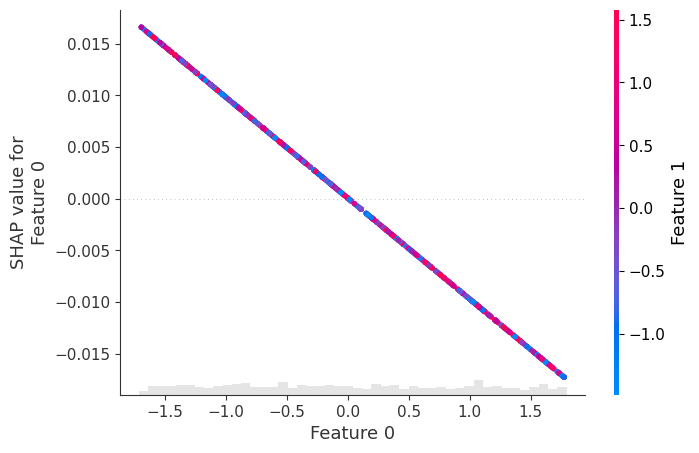

In [257]:
# import sklearn

# import shap

# get standardized data
# X, y = shap.datasets.california()
# scaler = sklearn.preprocessing.StandardScaler()
# scaler.fit(X)
# X_std = scaler.transform(X)

# train the linear model
# model = sklearn.linear_model.LinearRegression().fit(X_std, y)

# explain the model's predictions using SHAP
explainer = shap.explainers.Linear(lr, x_test)
shap_values_linear = explainer(x_test)

# visualize the model's dependence on the first feature
# shap.plots.scatter(shap_values_linear[:, 0])
shap.plots.scatter(shap_values_linear[:, 0], color=shap_values_linear[:, 1])

In [240]:
X.columns

Index(['cases', 'customers', 'customer_type', 'period', 'period_count'], dtype='object')

In [239]:
shap_values_linear.feature_names

['cases', 'customers', 'customer_type', 'period', 'period_count']

Manually need to map feature name to index to show in plot

In [ ]:
# we add back the feature names 
for i, c in enumerate(X.columns):
    shap_values_linear.feature_names[i] = c

In [259]:
shap_values_linear.feature_names

['cases', 'customers', 'customer_type', 'period', 'period_count']

## Cases

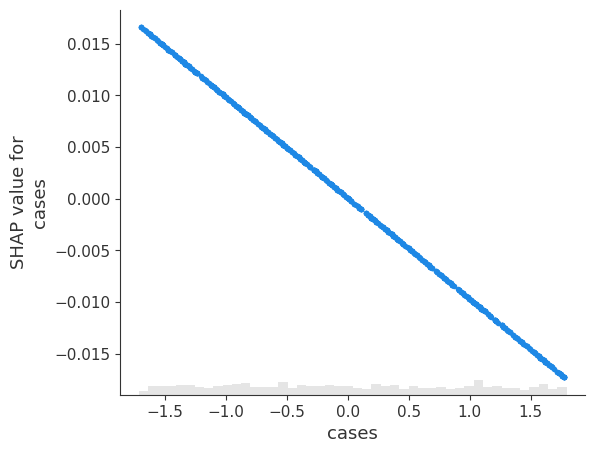

In [260]:

# visualize the model's dependence on the first feature again, now in the new original feature space
shap.plots.scatter(shap_values_linear[:, 0])

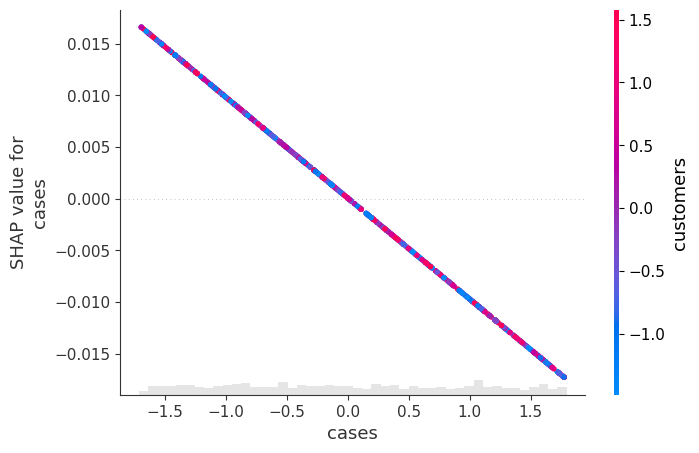

In [268]:
shap.plots.scatter(shap_values_linear[:, 0], color=shap_values_linear[:, 1])

## Customers

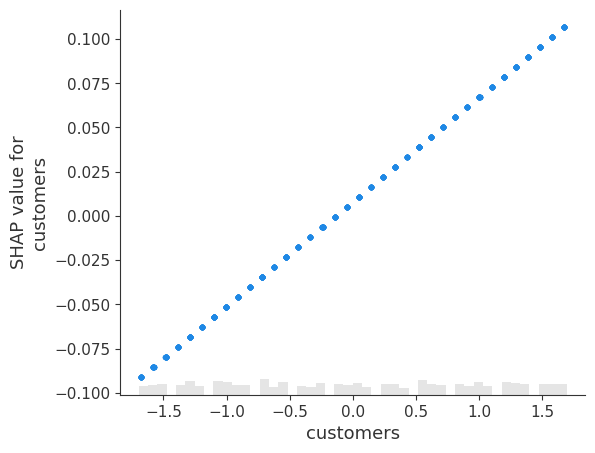

In [261]:
shap.plots.scatter(shap_values_linear[:, 1])

## Customer Type

Note: this plot may not be as helpful here. May be better for classification.

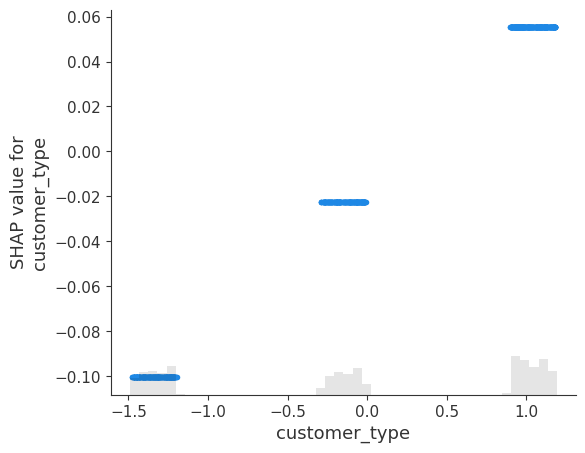

In [262]:
shap.plots.scatter(shap_values_linear[:, 2])

## Period

Note: this plot may not be as helpful here. May be better for classification.

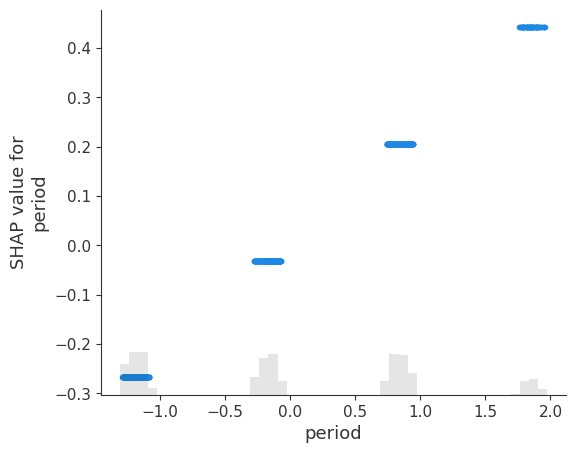

In [263]:
shap.plots.scatter(shap_values_linear[:, 3])

## Period Count

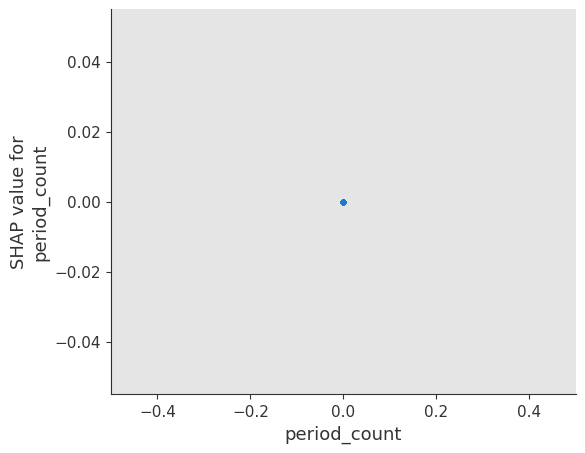

In [265]:
shap.plots.scatter(shap_values_linear[:, 4])

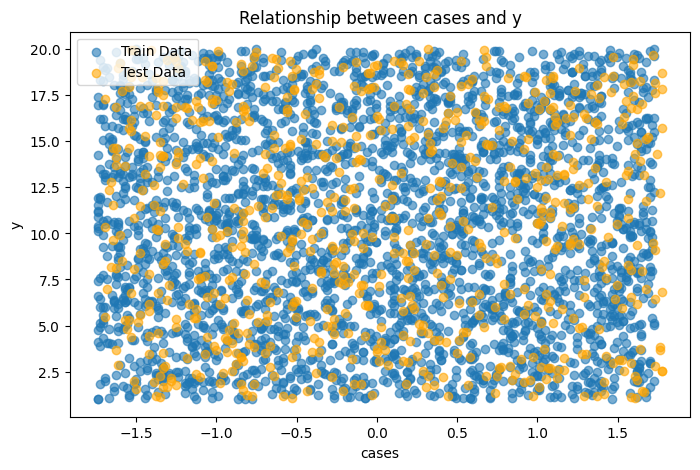

In [266]:
import matplotlib.pyplot as plt

# Specify the feature you want to plot against y
feature_name = "cases"  # Replace with the desired feature name
feature_index = X.columns.get_loc(feature_name)  # Get the index of the feature

# Plot the relationship
plt.figure(figsize=(8, 5))
plt.scatter(x_train[:, feature_index], y_train, alpha=0.6, label="Train Data")
plt.scatter(x_test[:, feature_index], y_test, alpha=0.6, label="Test Data", color="orange")
plt.title(f"Relationship between {feature_name} and y")
plt.xlabel(feature_name)
plt.ylabel("y")
plt.legend()
plt.show()